
# LangGraph Reflection 机制开发指南

本指南详细介绍了如何在 **LangGraph** 中构建基于大语言模型（LLM）的 **Reflection（反思）** 机制。

Reflection 是一种重要的模型能力，通过让模型观察其过去的步骤和外部环境反馈，评估自身行为的质量，并不断改进输出。在生成与反思的循环中，模型可以逐步优化内容，从而提升生成质量和用户满意度。

Reflection 机制被广泛应用于生成任务中，例如文章写作、内容修改与反馈、以及智能助理等场景。通过引导 LLM 进行自我反思和用户反馈处理，开发者可以让模型在多轮交互中自动调整其生成的内容，达到高效、精准、结构完善的输出。



在本指南中，我们会逐步演示如何搭建这一机制，包括从基础的环境配置到生成器和反思器的构建，再到如何使用 LangGraph 状态图实现生成-反思循环的完整流程。无论您是为文章生成、内容评估，还是其他复杂任务设计 LLM 代理，本指南都将为您提供详细的开发思路和实用的代码示例。

![reflection](./images/reflection.png)

通过本指南，您将学习如何：
1. 设置开发环境并安装所需包；
2. 定义和生成灵活结构的文章，不局限于传统的五段式；
3. 通过反思机制批改生成内容，并提供详细反馈；
4. 构建反思与生成的状态循环，使模型持续改进生成内容。

本开发指南适合任何希望构建复杂 LLM 任务的开发者，特别是需要实现生成-反思流程、文章批改反馈、或其他高级交互任务的场景。


## 1. 环境设置
首先，安装所需的包并设置API密钥：

In [1]:
%%capture --no-stderr
%pip install langchain langgraph langchain-ollama tavily-python

In [2]:
import getpass
import os

# 定义一个帮助函数来检查环境变量，如果不存在则提示用户输入
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"请输入您的 {var}")

# 设置 OpenAI 和 Langchain API 密钥
# _set_if_undefined("OPENAI_API_KEY")
# _set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")


## 2. LangSmith开发配置
LangSmith能够帮助您快速发现问题并提高LangGraph项目的性能。通过LangSmith，您可以使用跟踪数据来调试、测试和监控基于LangGraph构建的LLM应用程序。

In [3]:
# 在 LangSmith 中添加追踪功能
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Reflection"

## 3. 定义写作助手智能体

我们定义的这个助手是一个写作助手，旨在为用户生成高质量、结构清晰且引人入胜的文章。它的任务是根据用户的请求撰写内容，无论是短文、长篇、议论文还是其他类型的文章，都能够灵活应对。助手会专注于文章的清晰度、结构和质量，确保输出的内容是精心打磨过的。如果用户对生成的内容有反馈或建议，助手还能够根据这些反馈改进和优化文章，使其更符合用户的期望。这种互动机制保证了写作过程的灵活性和个性化，从而让用户获得更符合需求的成品。


### System Prompt 详细解释：
1. **"You are a writing assistant"**：写作助手的角色设定，让模型明确其任务是帮助用户进行写作。
   
2. **"well-crafted, coherent, and engaging articles"**：描述了文章应该具备的特性，包括“精心撰写的、连贯的和吸引人的”，但没有限制文章的具体结构，可以是不同类型的文章（如叙述文、议论文等）。

3. **"Focus on clarity, structure, and quality"**：明确了撰写时需要关注的核心要素：清晰度、结构性和质量，确保输出内容优秀。

4. **"revise and improve the writing"**：模型可以根据用户的反馈进行修改和优化，保持互动的灵活性。


In [4]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
#from langchain_ollama.chat_models import ChatOllama

writer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a writing assistant tasked with creating well-crafted, coherent, and engaging articles based on the user's request."
            " Focus on clarity, structure, and quality to produce the best possible piece of writing."
            " If the user provides feedback or suggestions, revise and improve the writing to better align with their expectations.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)


writer = writer_prompt | ChatOpenAI(model="gpt-4o-mini")

# writer = writer_prompt | ChatOllama(
#     model="llama3.1:8b-instruct-q8_0",
#     max_tokens=8192,
#     temperature=1.2,
# )

In [5]:
article = ""

topic = HumanMessage(
    content="参考水浒传的风格，改写吴承恩的西游记中任意篇章"
)

for chunk in writer.stream({"messages": [topic]}):
    print(chunk.content, end="")
    article += chunk.content

在这片神异的土地上，万里长空之下，风云变幻。此时，唐三藏师徒四人正行于西天取经的路上，心中各怀心事，神情各异。

师父唐三藏，身披袈裟，手持经卷，虔诚而坚定。他心中只想求取真经，普度众生；而身后，那猢狲精灵孙悟空则是一副不羁的模样，双眼闪烁，似乎在思索着什么，时不时放眼四周，想要寻找些乐趣。猪八戒则一边走，一边嘴里唠叨着：“师父，前面那座山看起来不错，咱们能不能歇歇脚，吃点好吃的？”而沙悟净则沉默寡言，默默扛着行李，心中思虑重重。

这日，四人行至一片妖风阵阵的山林中，忽然，一道黑影闪过，随即一声长啸，山崩地裂，竟有一头巨妖窜出，直扑唐三藏而来。孙悟空见状，立刻拔出金箍棒，怒喝道：“妖孽，休得猖狂！”他一跃而起，金光闪烁，直逼妖怪。

那妖怪乃是山中一只千年老鹰，修炼成精，力大无比。它展翅欲飞，张嘴便喷出一阵狂风，直逼三藏等人。唐三藏心中略有惧意，然而见悟空斗志昂扬，亦不敢退缩，默念佛号，祈求诸佛保佑。

“大胆妖孽，今日我定要将你打败！”孙悟空喝道，手中金箍棒如虹般舞动，直击妖怪的头顶。妖怪见状，急忙扭身躲避，却不想被悟空一棒打中，哀嚎一声，跌落于地。

“好！”猪八戒见状，顾不得口水流淌，立刻奔上前去，想要趁机来上一击。他一边挥舞着九齿钉耙，一边口中念叨：“这妖怪真是好吃，打败了咱们就可以大快朵颐了！”

沙悟净则在一旁默默观察，心中想着如何才能更好地协助师兄们。就在这时，妖怪怒吼一声，奋力挣扎，居然从地上爬起，张嘴再度喷出狂风，想要将四人一举击退。

然而，三藏在此时心中坚定，举手念起咒语，佛光普照，顿时风势减弱，妖怪的攻击也被压制。悟空见状，乘势而上，金箍棒如电，直取妖怪的心口。随着一声巨响，妖怪顿时被打得体无完肤，奄奄一息。

“师父，快让他认错！”八戒在一旁催促道。

唐三藏心中慈悲，见妖怪如此可怜，缓缓说道：“若你愿意悔过自新，便可免去一死。”

妖怪听了这番劝诫，心中感动，连忙跪下，痛哭流涕：“我愿意改过！请大师慈悲，饶我一命！”

唐三藏见状，点了点头，便让悟空收回了金箍棒。妖怪感激涕零，发誓以后不再为祸人间。师徒四人继续踏上了西天的征途，山川依旧，行人不息。

这便是西行路上的一段传奇，师徒之间的情义，以及那无尽的庙堂之光，正是他们心中坚定的信仰所指引的方向。

In [6]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(article))

在这片神异的土地上，万里长空之下，风云变幻。此时，唐三藏师徒四人正行于西天取经的路上，心中各怀心事，神情各异。

师父唐三藏，身披袈裟，手持经卷，虔诚而坚定。他心中只想求取真经，普度众生；而身后，那猢狲精灵孙悟空则是一副不羁的模样，双眼闪烁，似乎在思索着什么，时不时放眼四周，想要寻找些乐趣。猪八戒则一边走，一边嘴里唠叨着：“师父，前面那座山看起来不错，咱们能不能歇歇脚，吃点好吃的？”而沙悟净则沉默寡言，默默扛着行李，心中思虑重重。

这日，四人行至一片妖风阵阵的山林中，忽然，一道黑影闪过，随即一声长啸，山崩地裂，竟有一头巨妖窜出，直扑唐三藏而来。孙悟空见状，立刻拔出金箍棒，怒喝道：“妖孽，休得猖狂！”他一跃而起，金光闪烁，直逼妖怪。

那妖怪乃是山中一只千年老鹰，修炼成精，力大无比。它展翅欲飞，张嘴便喷出一阵狂风，直逼三藏等人。唐三藏心中略有惧意，然而见悟空斗志昂扬，亦不敢退缩，默念佛号，祈求诸佛保佑。

“大胆妖孽，今日我定要将你打败！”孙悟空喝道，手中金箍棒如虹般舞动，直击妖怪的头顶。妖怪见状，急忙扭身躲避，却不想被悟空一棒打中，哀嚎一声，跌落于地。

“好！”猪八戒见状，顾不得口水流淌，立刻奔上前去，想要趁机来上一击。他一边挥舞着九齿钉耙，一边口中念叨：“这妖怪真是好吃，打败了咱们就可以大快朵颐了！”

沙悟净则在一旁默默观察，心中想着如何才能更好地协助师兄们。就在这时，妖怪怒吼一声，奋力挣扎，居然从地上爬起，张嘴再度喷出狂风，想要将四人一举击退。

然而，三藏在此时心中坚定，举手念起咒语，佛光普照，顿时风势减弱，妖怪的攻击也被压制。悟空见状，乘势而上，金箍棒如电，直取妖怪的心口。随着一声巨响，妖怪顿时被打得体无完肤，奄奄一息。

“师父，快让他认错！”八戒在一旁催促道。

唐三藏心中慈悲，见妖怪如此可怜，缓缓说道：“若你愿意悔过自新，便可免去一死。”

妖怪听了这番劝诫，心中感动，连忙跪下，痛哭流涕：“我愿意改过！请大师慈悲，饶我一命！”

唐三藏见状，点了点头，便让悟空收回了金箍棒。妖怪感激涕零，发誓以后不再为祸人间。师徒四人继续踏上了西天的征途，山川依旧，行人不息。

这便是西行路上的一段传奇，师徒之间的情义，以及那无尽的庙堂之光，正是他们心中坚定的信仰所指引的方向。

----------
## 4. 定义审阅老师智能体

下面我们使用反思机制批改生成的作文，生成一篇作文的反馈和建议。

模型扮演“老师”角色，针对用户提交的作文进行打分、批改和提供改进建议。

### System Prompt 详细解释：

- **"You are a teacher grading an essay submission."**
  - 模型被设定为一个老师角色，专门负责为用户提交的作文进行批改。这一角色定位帮助模型理解其任务是提供具有建设性的反馈和评价。
  
- **"Generate critique and recommendations for the user's submission."**
  - 模型需要生成作文的批评与建议。它不只是评估作文的好坏，还需要指出需要改进的地方，并提出具体的建议。

- **"Provide detailed recommendations, including requests for length, depth, style, etc."**
  - 这一部分进一步明确了反馈的细节，要求模型给出细致的建议。这包括：
    - **Length（长度）**：文章的字数是否合适，是否需要扩展或删减。
    - **Depth（深度）**：是否需要更深入的分析或讨论。
    - **Style（风格）**：文章的写作风格是否合适，是否符合目标读者或主题的需求。
  
这一设定确保了模型不仅给出基本反馈，还可以根据文章的具体问题提出具体的改进意见，帮助用户更好地提升其写作。

In [8]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a teacher grading an article submission. writer critique and recommendations for the user's submission."
            " Provide detailed recommendations, including requests for length, depth, style, etc.",

        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# reflect = reflection_prompt | ChatOllama(
#     model="llama3.1:8b-instruct-q8_0",
#     max_tokens=8192,
#     temperature=0.2,
# )

reflect = reflection_prompt | ChatOpenAI(model="gpt-4o-mini")

In [9]:
reflection = ""

# 将主题（topic）和生成的文章（article）作为输入发送给反思智能体
for chunk in reflect.stream({"messages": [topic, HumanMessage(content=article)]}):
    print(chunk.content, end="")
    reflection += chunk.content

您的改写版本展示了对《西游记》情节的再创作，整体上保持了原著的风格和气氛，但仍有一些可以改进的地方，以增强文章的深度和表现力。以下是我对您的作品的详细评估和建议：

### 1. 内容深度
- **情感描写**：您可以进一步深入角色内心的感受，特别是唐三藏和孙悟空之间的师徒情感。例如，唐三藏在面对妖怪时的内心挣扎、他的慈悲心如何与对危险的恐惧相碰撞等。
- **背景描写**：在描述山林和妖怪时，可以增加一些细节，描绘山林的神秘与妖怪的威猛，使读者更能感受到环境的威胁和氛围的紧张。

### 2. 语言风格
- **古文风格**：您可以尝试使用更多古典词汇和句式来增强文章的古风气息。例如，使用“然”而非“然而”，“乃”而非“是”等，使整体语言更贴近《水浒传》的风格。
- **修辞手法**：运用更多的修辞手法，如比喻、拟人等，可以使文章更具表现力。例如，可以把风云与妖怪的出现进行类比，增加戏剧性。

### 3. 人物刻画
- **角色性格**：可以更突出孙悟空的机智与调皮，猪八戒的贪吃与幽默，沙悟净的沉稳与忠诚，让每个角色在互动中更加鲜活。
- **对话风格**：对话部分可以更具特色，比如让猪八戒的一些话更幽默或调皮，让人一看就能感受到他的个性。

### 4. 情节发展
- **冲突与解决**：在妖怪的对抗中，您可以增加一些细节，例如孙悟空如何巧妙地运用战斗技巧，或者在战斗中出现的转折点，使情节更紧凑。
- **结尾部分**：结尾可以增加一些反思，唐三藏如何看待妖怪的悔过，是否会影响他对取经之路的理解，进一步深化主题。

### 5. 文章长度
- **扩展内容**：考虑将文章长度增加至1500字左右，这样可以让您有更多空间去描写细节、深化角色和情感，并更完整地呈现故事的发展。

### 总结
您的作品有很好的基础，展示了对《西游记》故事的理解和对角色的把握。通过加强情感描写、细节刻画和语言风格，您的改写将更加生动且富有深度。期待您在未来的作品中继续探索和提升！

In [10]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(reflection))

您的改写版本展示了对《西游记》情节的再创作，整体上保持了原著的风格和气氛，但仍有一些可以改进的地方，以增强文章的深度和表现力。以下是我对您的作品的详细评估和建议：

### 1. 内容深度
- **情感描写**：您可以进一步深入角色内心的感受，特别是唐三藏和孙悟空之间的师徒情感。例如，唐三藏在面对妖怪时的内心挣扎、他的慈悲心如何与对危险的恐惧相碰撞等。
- **背景描写**：在描述山林和妖怪时，可以增加一些细节，描绘山林的神秘与妖怪的威猛，使读者更能感受到环境的威胁和氛围的紧张。

### 2. 语言风格
- **古文风格**：您可以尝试使用更多古典词汇和句式来增强文章的古风气息。例如，使用“然”而非“然而”，“乃”而非“是”等，使整体语言更贴近《水浒传》的风格。
- **修辞手法**：运用更多的修辞手法，如比喻、拟人等，可以使文章更具表现力。例如，可以把风云与妖怪的出现进行类比，增加戏剧性。

### 3. 人物刻画
- **角色性格**：可以更突出孙悟空的机智与调皮，猪八戒的贪吃与幽默，沙悟净的沉稳与忠诚，让每个角色在互动中更加鲜活。
- **对话风格**：对话部分可以更具特色，比如让猪八戒的一些话更幽默或调皮，让人一看就能感受到他的个性。

### 4. 情节发展
- **冲突与解决**：在妖怪的对抗中，您可以增加一些细节，例如孙悟空如何巧妙地运用战斗技巧，或者在战斗中出现的转折点，使情节更紧凑。
- **结尾部分**：结尾可以增加一些反思，唐三藏如何看待妖怪的悔过，是否会影响他对取经之路的理解，进一步深化主题。

### 5. 文章长度
- **扩展内容**：考虑将文章长度增加至1500字左右，这样可以让您有更多空间去描写细节、深化角色和情感，并更完整地呈现故事的发展。

### 总结
您的作品有很好的基础，展示了对《西游记》故事的理解和对角色的把握。通过加强情感描写、细节刻画和语言风格，您的改写将更加生动且富有深度。期待您在未来的作品中继续探索和提升！

In [11]:
from typing import Annotated  # 用于类型注解
from langgraph.graph import END, StateGraph, START  # 导入状态图的相关常量和类
from langgraph.graph.message import add_messages  # 用于在状态中处理消息
from langgraph.checkpoint.memory import MemorySaver  # 内存保存机制，用于保存检查点
from typing_extensions import TypedDict  # 用于定义带有键值对的字典类型

# 定义状态类，使用TypedDict以保存消息
class State(TypedDict):
    messages: Annotated[list, add_messages]  # 使用注解确保消息列表使用add_messages方法处理

# 异步生成节点函数：生成内容（如作文）
# 输入状态，输出包含新生成消息的状态
async def generation_node(state: State) -> State:
    # 调用生成器(writer)，并将消息存储到新的状态中返回
    return {"messages": [await writer.ainvoke(state['messages'])]}

# 异步反思节点函数：对生成的内容进行反思和反馈
# 输入状态，输出带有反思反馈的状态
async def reflection_node(state: State) -> State:
    # 创建一个消息类型映射，ai消息映射为HumanMessage，human消息映射为AIMessage
    cls_map = {"ai": HumanMessage, "human": AIMessage}
    
    # 处理消息，保持用户的原始请求（第一个消息），转换其余消息的类型
    translated = [state['messages'][0]] + [
        cls_map[msg.type](content=msg.content) for msg in state['messages'][1:]
    ]
    
    # 调用反思器(reflect)，将转换后的消息传入，获取反思结果
    res = await reflect.ainvoke(translated)
    
    # 返回新的状态，其中包含反思后的消息
    return {"messages": [HumanMessage(content=res.content)]}


In [12]:
MAX_ROUND = 6

# 定义条件函数，决定是否继续反思过程
# 如果消息数量超过6条，则终止流程
def should_continue(state: State):
    if len(state["messages"]) > MAX_ROUND:
        return END  # 达到条件时，流程结束
    return "reflect"  # 否则继续进入反思节点

In [17]:
# 创建状态图，传入初始状态结构
builder = StateGraph(State)

# 在状态图中添加"writer"节点，节点负责生成内容
builder.add_node("writer", generation_node)

# 在状态图中添加"reflect"节点，节点负责生成反思反馈
builder.add_node("reflect", reflection_node)

# 定义起始状态到"writer"节点的边，从起点开始调用生成器
builder.add_edge(START, "writer")

# 添加从"reflect"节点回到"writer"节点的边，进行反复的生成-反思循环
builder.add_edge("reflect", "writer")

# 在"writer"节点和"reflect"节点之间添加条件边
# 判断是否需要继续反思，或者结束
builder.add_conditional_edges("writer", should_continue)

# 创建内存保存机制，允许在流程中保存中间状态和检查点
memory = MemorySaver()

# 编译状态图，使用检查点机制
graph = builder.compile(checkpointer=memory)

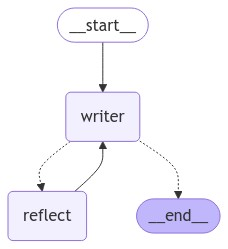

In [18]:
# 可视化图
from IPython.display import Image, display

try:
    display(
        Image(
            graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

In [19]:
from IPython.display import Markdown, display

# 定义装饰器，记录函数调用次数
def track_steps(func):
    step_counter = {'count': 0}  # 用于记录调用次数
    
    def wrapper(event, *args, **kwargs):
        # 增加调用次数
        step_counter['count'] += 1
        # 在函数调用之前打印 step
        display(Markdown(f"## Round {step_counter['count']}"))
        # 调用原始函数
        return func(event, *args, **kwargs)
    
    return wrapper

# 使用装饰器装饰 pretty_print_event_markdown 函数
@track_steps
def pretty_print_event_markdown(event):
    # 如果是生成写作部分
    if 'writer' in event:
        generate_md = "#### 写作生成:\n"
        for message in event['writer']['messages']:
            generate_md += f"- {message.content}\n"
        display(Markdown(generate_md))
    
    # 如果是反思评论部分
    if 'reflect' in event:
        reflect_md = "#### 评论反思:\n"
        for message in event['reflect']['messages']:
            reflect_md += f"- {message.content}\n"
        display(Markdown(reflect_md))

In [20]:
inputs = {
    "messages": [
        HumanMessage(content="参考西游记唐僧的说话风格，写一篇奉劝年轻人努力工作的文章")
    ],
}

config = {"configurable": {"thread_id": "1"}}

async for event in graph.astream(inputs, config):
    pretty_print_event_markdown(event)


## Round 1

#### 写作生成:
- **年轻人，努力工作，方能成就未来**

诸位年轻的朋友们，今日我欲与尔等闲话一番，言及奋斗与努力之道。常言道：“天道酬勤”，若无辛勤耕耘，何以得丰硕之果？在这纷繁复杂的世界中，唯有勤勉不懈，方能迎来光辉灿烂的明天。

昔日我曾游历西天，途经重重困难，遇险阻无数，然我始终不懈怠，坚定信念，终得真经，回归大唐。此中道理岂非也可借鉴于尔等之工作与生活乎？如若你心中有梦，便需脚踏实地，勇敢追寻。即使前路漫漫，荆棘密布，但只要不畏艰难，步履不停，必能见到希望的曙光。

尔等年轻之时，正是意气风发、拼搏向上的最佳时机。古人云：“少壮不努力，老大徒伤悲。”年轻乃是财富，时间乃是资本，若不善加利用，将来只会为自己的人生感到惋惜。切记，成功之路并非一帆风顺，需付出汗水与智慧，方能迎来丰收之日。

在工作中，汝等应当树立目标，制定计划，持之以恒。无论是学习新知，还是提升技能，皆需保持一颗勤奋学习、不断进取的心。对于每一项任务，务必认真对待，做到尽善尽美。如此，才能在职场中立于不败之地，获得他人的赞赏与信任。

此外，人与人之间的合作亦不可忽视，团队的力量往往能成就更大的梦想。与同伴互助共勉，共同面对挑战，便能在互相扶持中，一同成长。正如师徒四人，各展所长，最终齐心协力，克服重重难关，取得成功。

年轻的朋友们，愿你们以勤奋为舟，以努力为桨，乘风破浪，勇往直前。记住，未来的光辉在于今日的努力，愿你们都能在追梦的旅途中，谱写出属于自己的辉煌篇章。


## Round 2

#### 评论反思:
- **文章评析与建议**

首先，感谢你提交的文章。你以唐僧的口吻，传达了努力工作的重要性，整体风格符合你所期望的古典韵味和哲理深邃感。以下是我对你的文章的一些具体评价和建议，希望能帮助你进一步提升作品的质量。

### 优点：
1. **风格契合**：文章成功模仿了唐僧的说话方式，使用了古文中的一些句式和词汇，使得整篇文章充满了古典气息。
2. **主题明确**：文章清晰地传达了年轻人应该努力工作的理念，并通过寓言式的方法引入了实践经验，增强了说服力。
3. **结构合理**：文章的结构较为完整，开头引入主题，中间阐述道理，最后总结鼓励，逻辑清晰。

### 改进建议：
1. **增加长度与深度**：目前文章约为300字，建议你扩展到600字以上，增加更多的论据和实例。例如，可以结合现代社会的实际案例，说明努力工作如何改变个人命运，或引用一些名人的奋斗故事，增加文章的深度和说服力。
   
2. **加强情感共鸣**：可以通过增强情感描写来让读者产生共鸣，比如描述年轻人努力奋斗时的心路历程、内心的挣扎与坚持，这样能让读者更容易感同身受。

3. **语言丰富性**：虽然模仿唐僧的风格，但有些句子略显重复，建议在用词和句式上进行多样化的尝试。例如，使用更多修辞手法，增加比喻、排比等，来提高语言的表现力。

4. **引入反面例子**：可以考虑适当引入一些反面例子，说明不努力的后果，这样能形成鲜明对比，增强你的论点效果。

5. **结尾的力量**：结尾部分可以更加有力，考虑加入一句富有哲理的名言或警句，给人留下深刻的印象，增强文章的总结力。

### 总结：
你的文章在风格和结构上都表现出色，但在深度和情感方面还有提升的空间。通过增加内容的丰富性和情感的共鸣，能够使这篇文章更加吸引人。期待你重新修改后的作品！


## Round 3

...

#### 写作生成:
- 非常感谢您的细致评价和进一步的建议！我将根据您的反馈进行进一步的修改，以增强文章的结构清晰度、实用性以及呼吁力量。以下是修订后的版本：

---

**年轻人，努力工作，方能成就未来**

诸位年轻的朋友们，今日我欲与尔等闲话一番，言及奋斗与努力之道。常言道：“天道酬勤”，若无辛勤耕耘，何以得丰硕之果？在这纷繁复杂的世界中，唯有勤勉不懈，方能迎来光辉灿烂的明天。

昔日我曾游历西天，途经重重困难，遇险阻无数，然我始终不懈怠，坚定信念，终得真经，回归大唐。此中道理岂非也可借鉴于尔等之工作与生活乎？如若你心中有梦，便需脚踏实地，勇敢追寻。即使前路漫漫，荆棘密布，但只要不畏艰难，步履不停，必能见到希望的曙光。

尔等年轻之时，正是意气风发、拼搏向上的最佳时机。古人云：“少壮不努力，老大徒伤悲。”年轻乃是财富，时间乃是资本，若不善加利用，将来只会为自己的人生感到惋惜。切记，成功之路并非一帆风顺，需付出汗水与智慧，方能迎来丰收之日。

在工作中，汝等应当树立目标，制定计划，持之以恒。为此，建议使用时间管理工具，设定短期与长期的目标，逐步实现自己的理想。无论是学习新知，还是提升技能，皆需保持一颗勤奋学习、不断进取的心。对于每一项任务，务必认真对待，做到尽善尽美。如此，才能在职场中立于不败之地，获得他人的赞赏与信任。

然则，努力之路上，非但需自我鞭策，亦需与同伴携手共进。古语有云：“众志成城”，人与人之间的合作不可或缺。与同伴互助共勉，共同面对挑战，便能在互相扶持中，一同成长。正如师徒四人，各展所长，最终齐心协力，克服重重难关，取得成功。

若想以此道理为鉴，何妨想想那些成功人士的故事？比尔·盖茨、马云、乔布斯等人，皆是在无数个日夜的辛苦努力中，才得以成就伟大之业。他们的成功并非偶然，背后皆是无数个奋斗的瞬间与不懈的追求。相较之下，若缺乏努力，便如无舵之舟，终将漂泊无依，令人惋惜。此等对比，正是成功与失败的真实写照。

年轻的朋友们，愿你们以勤奋为舟，以努力为桨，乘风破浪，勇往直前。切记，未来的光辉在于今日的努力。愿你们都能在追梦的旅途中，谱写出属于自己的辉煌篇章。请铭记，行动之力源于内心的热忱与信念，愿你们坚定不移，直至成功的彼岸！

---

希望这次的修订能够更好地满足您的期望，并传达出更强的激励效果。如果您还有其他建议或需要进一步的调整，请随时告诉我！


## Round 6

#### 评论反思:
- 非常高兴看到你对文章进行了又一次有意义的修订！你的努力显然使得文章在结构、内容的实用性和呼吁力量上都有了显著的提升。以下是我对你最新版本的评价和建议：

### 优点：
1. **结构清晰**：通过分段处理，使得文章更具条理性，读者能够更轻松地跟随你的思路。
2. **实用性增强**：你增加了使用时间管理工具和设定目标的具体建议，这使得文章更具指导性，读者可以直接应用于实践。
3. **情感呼吁有力**：结尾部分用“行动之力源于内心的热忱与信念”这种富有感染力的语言，增强了激励效果，让读者感受到一种动力。

### 进一步建议：
1. **引入更多实例**：虽然你提到了比尔·盖茨、马云和乔布斯的例子，考虑再增加一些具体的故事或事例，尤其是与年轻人相关的奋斗经历，这样能让读者更容易产生共鸣。
   
2. **使用更生动的语言**：在某些部分，可以考虑使用比喻和形象化的语言，使得表达更为生动。例如，在描述“乘风破浪，勇往直前”时，可以加入一些具体的画面感，让读者更容易想象这幅图景。

3. **总结部分**：在最后的总结中，可以考虑加入一个更有力的号召性用语，激励年轻人立刻行动起来，比如“现在就是你们改变未来的时刻，不要犹豫，勇敢追梦！”

4. **调整某些句式**：某些句式可能稍显复杂，可以适当简化，使得句子更为流畅，便于读者理解。例如，“正如师徒四人，各展所长，最终齐心协力，克服重重难关，取得成功。” 可以简化为“如同师徒四人齐心协力，克服重重困难，最终取得成功。”

### 总结：
你的最新版本已经相当优秀，结构清晰且内容丰富，激励效果显著。通过进一步细化实例、语言生动性和总结的号召力，能够让文章更具吸引力和感染力。期待看到你最终的版本！如果你有其他问题或者需要更多建议，请随时联系我！


## Round 7

#### 写作生成:
- 非常感谢您对我修订版本的高度评价和进一步的建议！我将根据您的反馈进行再次修改，增加更多实例、使用更生动的语言，并强化总结部分的号召性。以下是最终修订后的版本：

---

**年轻人，努力工作，方能成就未来**

诸位年轻的朋友们，今日我欲与尔等闲话一番，言及奋斗与努力之道。常言道：“天道酬勤”，若无辛勤耕耘，何以得丰硕之果？在这纷繁复杂的世界中，唯有勤勉不懈，方能迎来光辉灿烂的明天。

昔日我曾游历西天，途经重重困难，遇险阻无数，然我始终不懈怠，坚定信念，终得真经，回归大唐。此中道理岂非也可借鉴于尔等之工作与生活乎？如若你心中有梦，便需脚踏实地，勇敢追寻。即使前路漫漫，荆棘密布，但只要不畏艰难，步履不停，必能见到希望的曙光。

尔等年轻之时，正是意气风发、拼搏向上的最佳时机。古人云：“少壮不努力，老大徒伤悲。”年轻乃是财富，时间乃是资本，若不善加利用，将来只会为自己的人生感到惋惜。切记，成功之路并非一帆风顺，需付出汗水与智慧，方能迎来丰收之日。

在工作中，汝等应当树立目标，制定计划，持之以恒。为此，建议使用时间管理工具，如“番茄钟”或“待办事项清单”，设定短期与长期的目标，逐步实现自己的理想。无论是学习新知，还是提升技能，皆需保持一颗勤奋学习、不断进取的心。对于每一项任务，务必认真对待，做到尽善尽美。如此，才能在职场中立于不败之地，获得他人的赞赏与信任。

然则，努力之路上，非但需自我鞭策，亦需与同伴携手共进。古语有云：“众志成城”，人与人之间的合作不可或缺。与同伴互助共勉，共同面对挑战，便能在互相扶持中，一同成长。如同师徒四人齐心协力，克服重重困难，最终取得成功。

若想以此道理为鉴，何妨想想那些成功人士的故事？比尔·盖茨在年少时便沉迷于编程，夜以继日地钻研，最终创立了微软；马云在面对无数次失败后，依然不屈不挠，最终创办了阿里巴巴，改变了整个电商行业。这些传奇故事不仅仅是成功的象征，更是努力与坚持的真实写照。相较之下，若缺乏努力，便如无舵之舟，终将漂泊无依，令人惋惜。

年轻的朋友们，愿你们以勤奋为舟，以努力为桨，乘风破浪，勇往直前。现在，就是你们改变未来的时刻！切记，未来的光辉在于今日的努力。请铭记，行动之力源于内心的热忱与信念，愿你们坚定不移，直至成功的彼岸！

---

希望这次的修订能更好地满足您的期望，增强文章的吸引力和感染力。如果您还有其他建议或者需要进一步调整的地方，请随时告诉我！


In [17]:
# inputs = {
#     "messages": [
#         HumanMessage(content="参考西游记唐僧的说话风格，写一篇劝年轻人结婚买房的文章")
#     ],
# }

# config = {"configurable": {"thread_id": "1"}}

# async for event in graph.astream(inputs, config):
#     pretty_print_event_markdown(event)


## Homework: 

1. 扩展本指南的 Reflection Agent，使其能够完成更通用的生成任务，包括但不限于代码、报告等；
2. 使用扩展后的 Reflection Agent 生成代码，实现在 GitHubSentinel 上新增一个信息渠道。

### 如何让 Reflection `System Prompt` 更加通用：

如果你想让这个 `System Prompt` 适用于更广泛的内容评估场景，不局限于作文，你可以做一些轻微的调整。例如：

```python
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a reviewer tasked with providing constructive critique and improvement suggestions for the user's submission."
            " Offer detailed feedback, including recommendations on clarity, structure, content depth, and style, as well as areas for improvement.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)
```

### 修改后的变化：
1. **角色定位更广泛**：从“老师”改为“审阅者”，这样不局限于评估作文，适用于各种类型的内容，包括文章、报告、甚至代码审查。
  
2. **批评与改进建议的灵活性**：从作文的“长度、深度、风格”拓展为“清晰度、结构、内容深度、风格”，这使得反馈更加多样化，适用于不同的内容类型。

通过这种方式，可以让模型在更多场景下提供高质量的评估和反馈。